<a href="https://colab.research.google.com/github/fathimanoorjahan03-afk/Assignment_SupervisedLearning/blob/main/Unsupervised_learning_casestudy_FathimaN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Adult Census Income Dataset – Unsupervised Learning Case Study
## Clustering Analysis using K-Means and Agglomerative Clustering

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/DSA/Unsupervised/adult_dataset.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Initial data understanding

In [3]:
df.shape

(48842, 15)

In [4]:
df.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [6]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [7]:
df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [8]:
df.duplicated().sum()

np.int64(16)

In [9]:
(df == '?').sum()

,0
age,0
workclass,1763
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1758
relationship,0
race,0
sex,0


In [10]:
cat_columns = df.select_dtypes(include = 'object').columns
cat_columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')

In [11]:
# Displaying unique values in categorical columns
for col in cat_columns:
  print(f'\n{col}')
  print(df[col].unique())


workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' nan 'Local-gov'
 '?' 'Self-emp-inc' 'Without-pay' 'Never-worked']

education
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

marital-status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' nan
 'Protective-serv' '?' 'Armed-Forces' 'Priv-house-serv']

relationship
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

race
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']

sex
['Male' 'Female']

native-country
[nan 'United-States' 'Cuba' 'Jamaica' 'India' '?' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras'

In [12]:
num_columns = df.select_dtypes(include = np.number).columns
num_columns

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

## Data Preprocessing


In [13]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', df.shape)

Shape after removing duplicates: (48826, 15)


In [14]:
# Replacing ? with NaN

df = df.replace('?', np.nan)

In [15]:
# Missing values sum after converting '?' to NaN

df.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


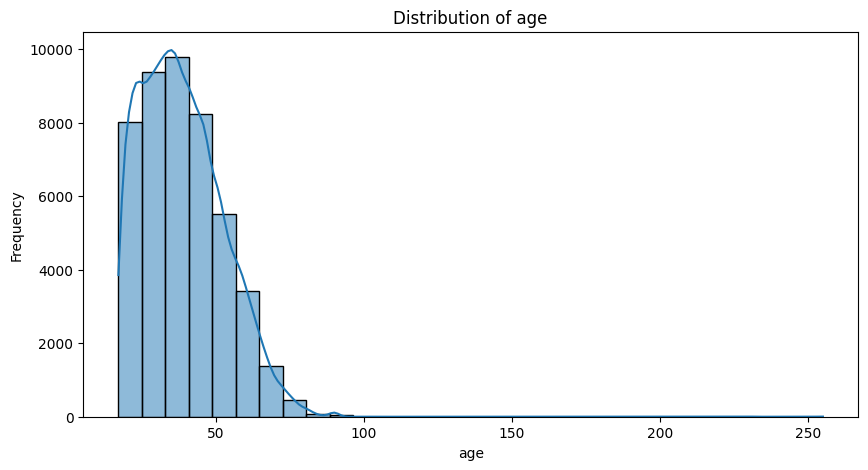

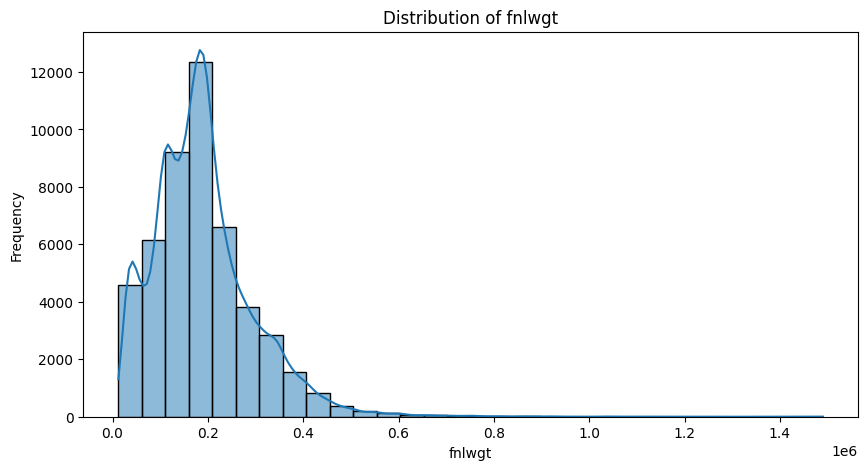

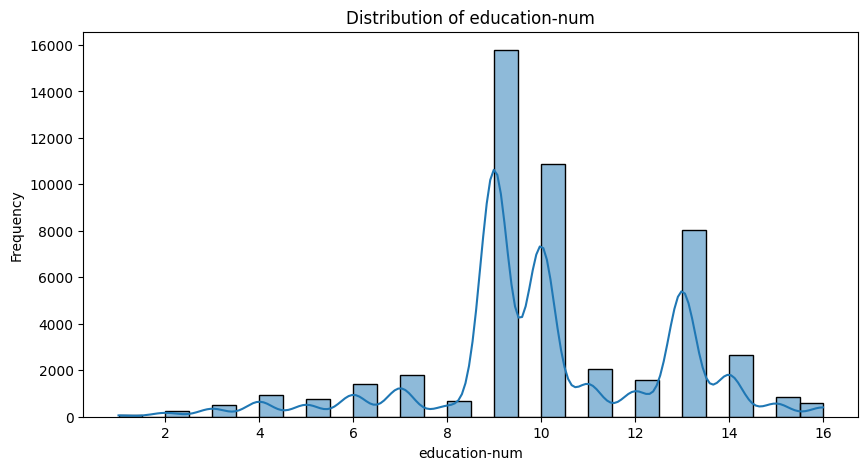

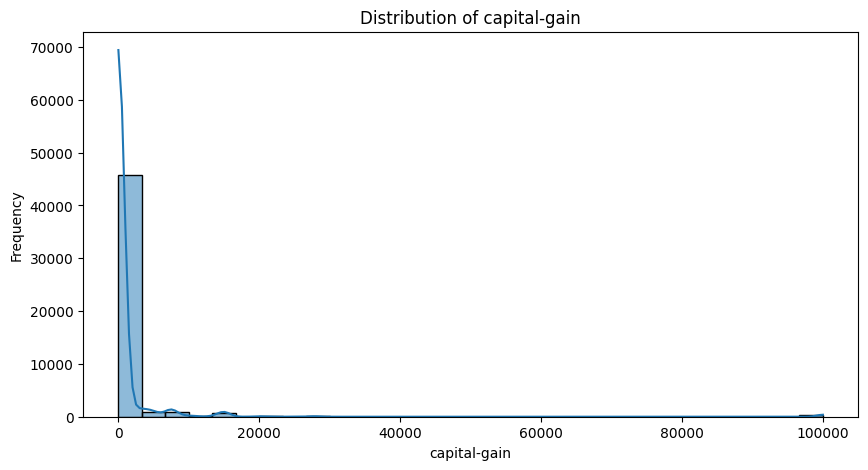

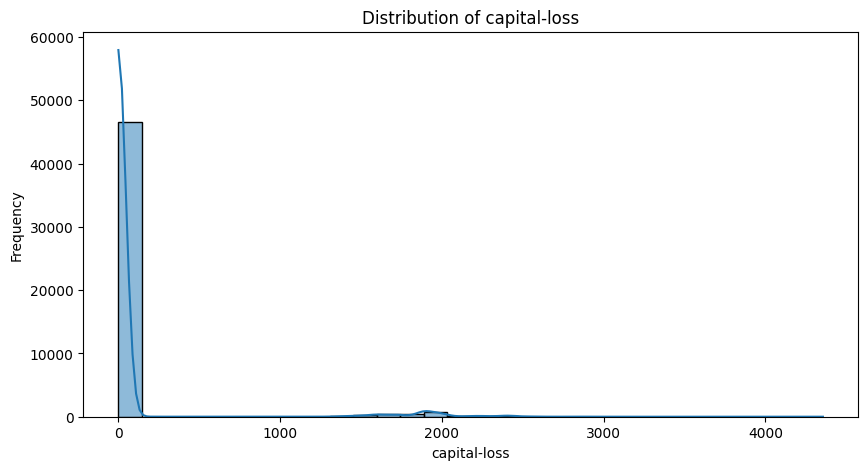

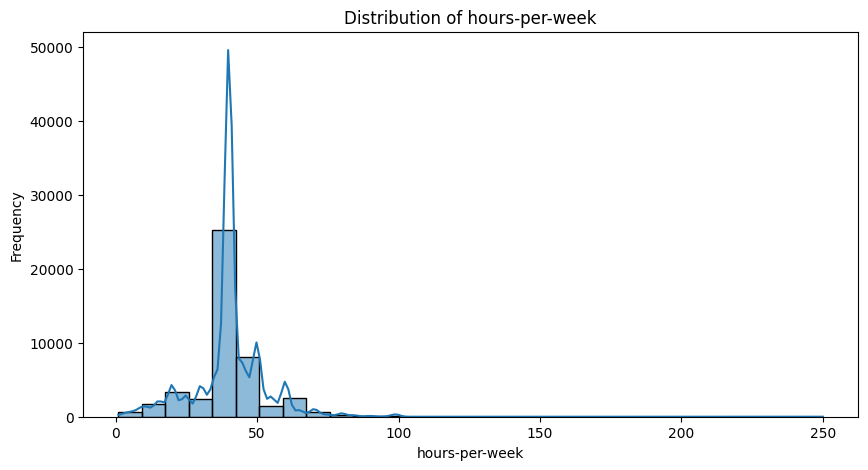

In [16]:
# Histograms for all numerical columns
for col in num_columns:
  plt.figure(figsize=(10, 5))
  sns.histplot(df[col], bins=30, kde=True)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

##Handling missing values

In [17]:
# Fill missing numerical values with median

df['age'] = df['age'].fillna(df['age'].median())
df['hours-per-week'] = df['hours-per-week'].fillna(df['hours-per-week'].median())

print(df[['age', 'hours-per-week']].isnull().sum())

age               0
hours-per-week    0
dtype: int64


In [18]:
#Fill missing categorical values with mode

categorical_missing_cols = ['workclass', 'occupation', 'native-country']

for col in categorical_missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#Missing values after categorical imputation
print(df[categorical_missing_cols].isnull().sum())

workclass         0
occupation        0
native-country    0
dtype: int64


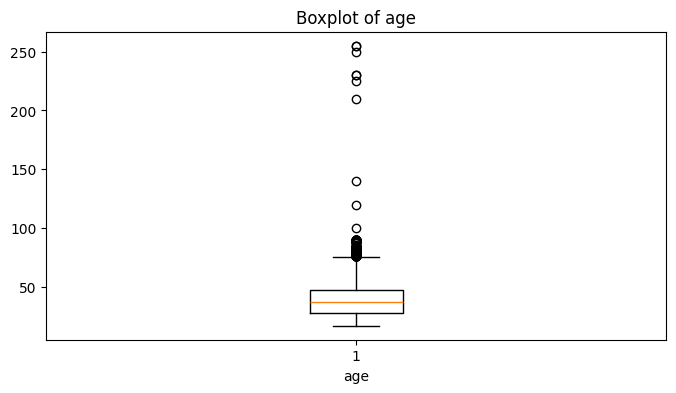

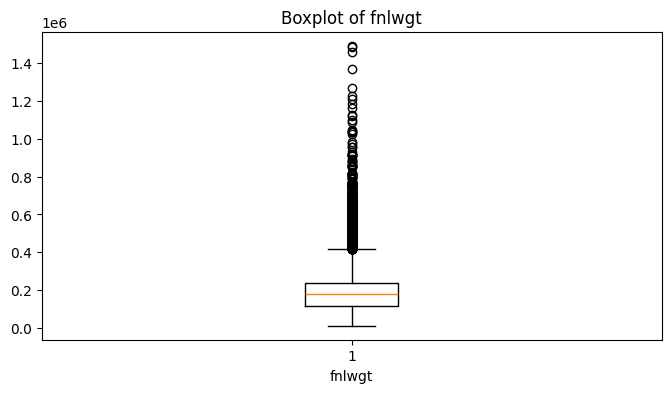

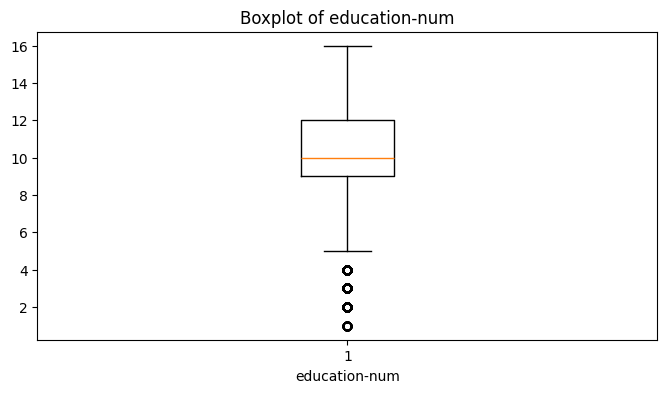

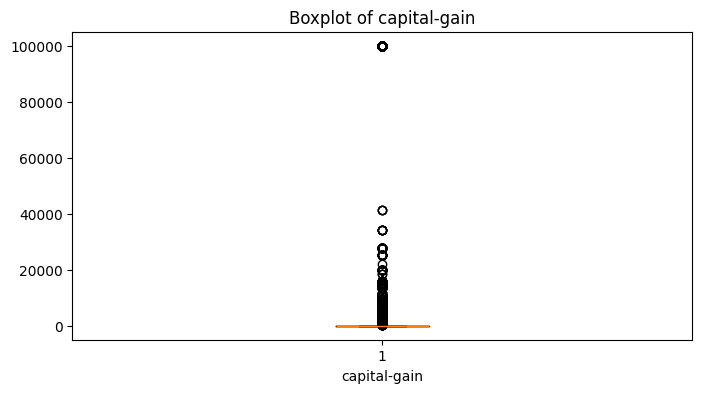

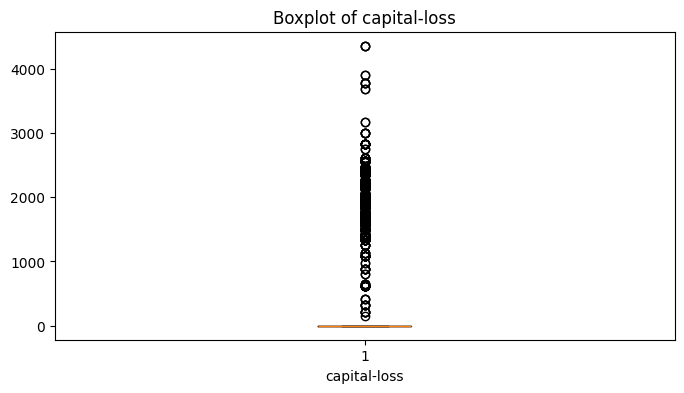

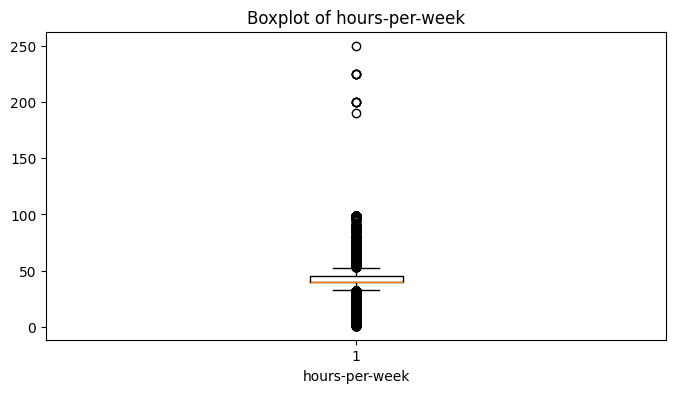

In [19]:
# Boxplots of all numerical columns

for col in num_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [20]:
df['capital-gain'].value_counts()

,count
capital-gain,
0,44791
15024,513
7688,410
7298,364
99999,244
...,...
1639,1
2387,1
7262,1


##correlation Heatmap

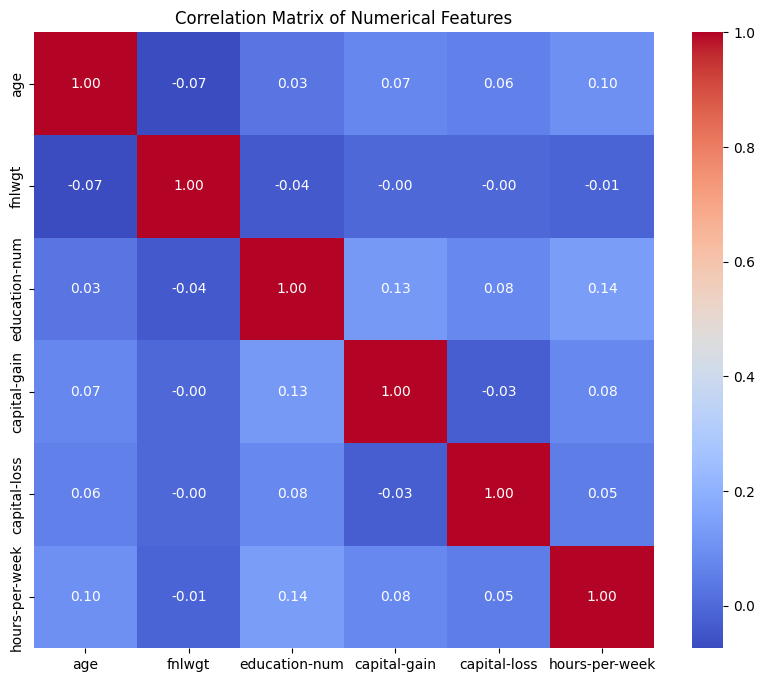

In [21]:
corr_matrix = df[num_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

##Outlier treatment

In [22]:
outlier_columns = ['age', 'hours-per-week']

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower:", lower_bound)
    print("Upper:", upper_bound)

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

age
Q1: 28.0
Q3: 47.0
IQR: 19.0
Lower: -0.5
Upper: 75.5
hours-per-week
Q1: 40.0
Q3: 45.0
IQR: 5.0
Lower: 32.5
Upper: 52.5


In [24]:
# Keep income separately for cluster profiling later

income = df['income'].copy()

df = df.drop(columns='income')

##Categorical Encoding

In [25]:
# One-hot encode categorical features

cat_columns = df.select_dtypes(include='object').columns
df = pd.get_dummies(df,columns=cat_columns,drop_first=True,dtype=int)

df.shape

(48826, 97)

##Feature Scaling

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled.shape

(48826, 97)

##Dimensionality Reduction (PCA)


In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA data shape:", X_pca.shape)
print("Explained variance by PC1 and PC2:")
print(pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

PCA data shape: (48826, 2)
Explained variance by PC1 and PC2:
[0.0354267  0.02757085]
Total explained variance: 0.06299755744152964


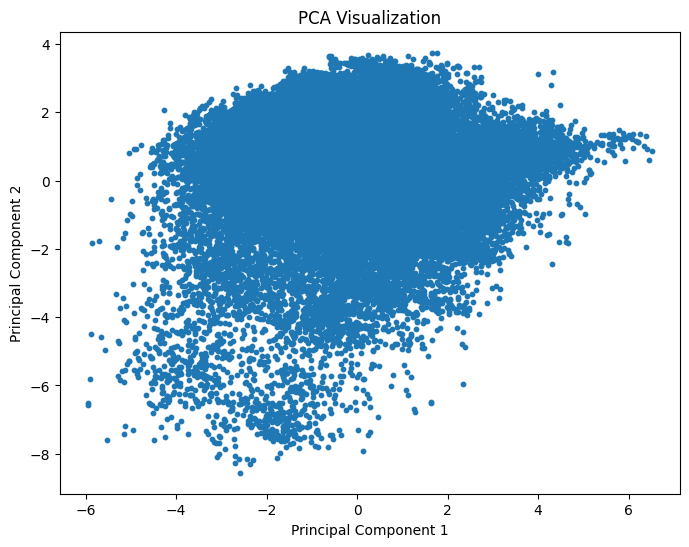

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0],X_pca[:, 1],s=10)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')
plt.show()

##Clustering Analysis

##K-Means Clustering

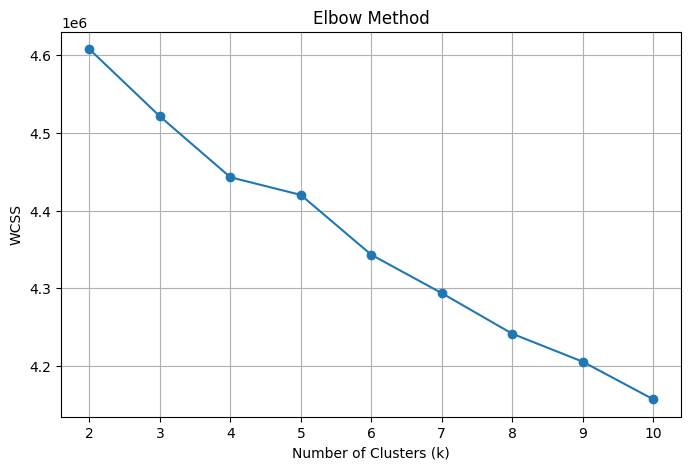

In [33]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid()
plt.show()

In [32]:
wcss

[4607684.094709461,
 4521216.945642608,
 4442892.713428994,
 4420141.960351633,
 4343149.846915811,
 4293761.348714543,
 4241539.590486068,
 4205545.301563296,
 4157201.0990631618]

##Silhouette Analysis

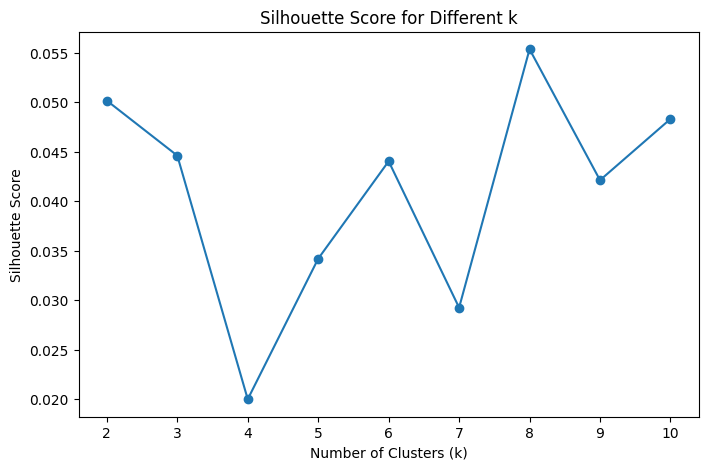

In [34]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.show()

In [35]:
# Final K-Means model

k = 8
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)
cluster_labels = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed.")

K-Means clustering completed.


In [37]:
# Cluster sizes

unique, counts = np.unique(cluster_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count}")

Cluster 0: 1574
Cluster 1: 18252
Cluster 2: 1551
Cluster 3: 7246
Cluster 4: 102
Cluster 5: 1952
Cluster 6: 4317
Cluster 7: 13832


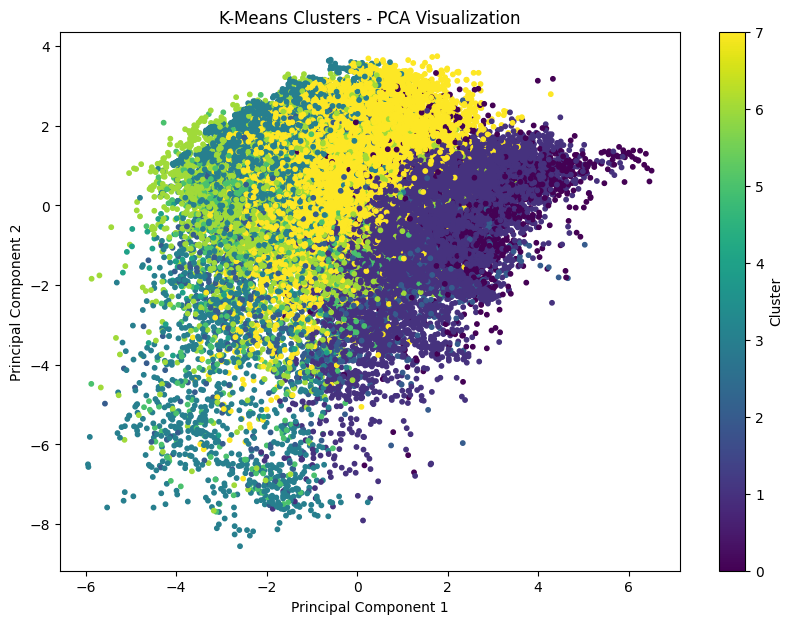

In [38]:
# Visualize K-Means clusters using PCA

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    s=10,
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters - PCA Visualization')
plt.colorbar(label='Cluster')

plt.show()

##Dendrogram Evaluation

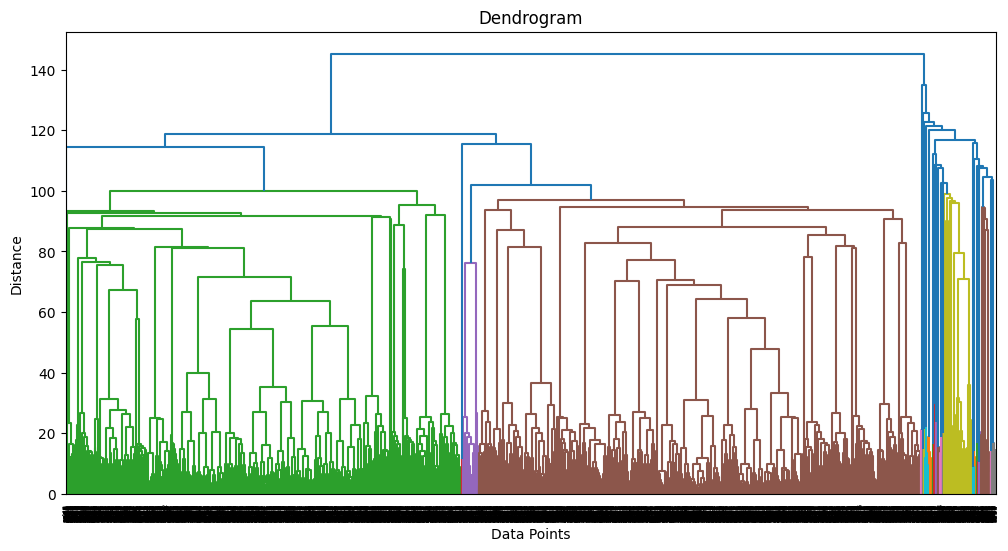

In [41]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Use a sample because the dataset is large
sample = X_scaled[:5000]

mergings = linkage(sample, method='ward')

plt.figure(figsize=(12, 6))

dendrogram(mergings)

plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

##Agglomerative Hierarchical Clustering

In [42]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=k,
    metric='euclidean',
    linkage='ward'
)

agg = agg.fit_predict(sample)

print("Agglomerative clustering completed.")

Agglomerative clustering completed.


In [43]:
X_pca_sample = X_pca[:5000]

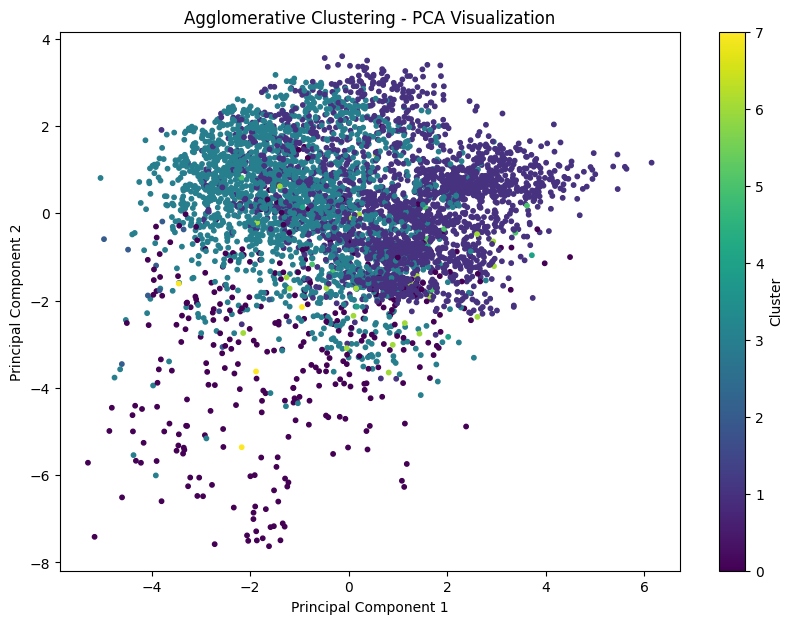

In [45]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_sample[:, 0],
    X_pca_sample[:, 1],
    c=agg,
    s=10,
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Agglomerative Clustering - PCA Visualization')
plt.colorbar(label='Cluster')

plt.show()

In [47]:
print("Agglomerative Silhouette Score:",
      round(silhouette_score(sample, agg), 4))

Agglomerative Silhouette Score: 0.0258


##Cluster Profiling

In [48]:
# Load original dataset for cluster profiling

profile_df = pd.read_csv("/content/drive/MyDrive/DSA/Unsupervised/adult_dataset.csv")

# Remove the same duplicate rows handled during preprocessing
profile_df = profile_df.drop_duplicates().reset_index(drop=True)

# Add K-Means cluster labels
profile_df['Cluster'] = cluster_labels
profile_df.shape

(48826, 16)

In [49]:
profile_df.groupby('Cluster')[
    ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
].mean().round(2)

,age,education-num,hours-per-week,capital-gain,capital-loss
Cluster,,,,,
0,46.05,11.14,48.47,5302.41,168.74
1,43.53,10.42,43.37,1569.25,120.71
2,37.76,11.00,40.05,1509.27,97.32
3,25.65,8.99,33.66,157.83,38.81
4,37.44,9.94,39.58,509.54,18.50
5,32.56,8.50,37.92,281.61,44.16
6,38.10,9.51,38.56,554.69,61.68
7,39.42,10.37,40.26,667.66,73.63


In [50]:
categorical_cols = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex'
]

cluster_categorical = profile_df.groupby('Cluster')[categorical_cols].agg(
    lambda x: x.mode()[0]
)

cluster_categorical

,workclass,education,marital-status,occupation,relationship,race,sex
Cluster,,,,,,,
0,Self-emp-inc,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,Male
1,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male
2,Private,Bachelors,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male
3,Private,Some-college,Never-married,Other-service,Own-child,White,Male
4,Private,HS-grad,Never-married,Other-service,Not-in-family,Black,Female
5,Private,HS-grad,Never-married,Handlers-cleaners,Husband,White,Male
6,Private,HS-grad,Never-married,Other-service,Not-in-family,Black,Female
7,Private,HS-grad,Never-married,Adm-clerical,Not-in-family,White,Female


In [52]:
profile_df['income'] = profile_df['income'].str.strip().str.rstrip('.')

In [53]:
profile_df['income'].value_counts()

,count
income,
<=50K,37139
>50K,11687


##  Compare Clusters with Income

In [54]:
income_profile = pd.crosstab(
    profile_df['Cluster'],
    profile_df['income'],
    normalize='index'
) * 100

income_profile.round(2)

income,<=50K,>50K
Cluster,,
0,44.03,55.97
1,54.63,45.37
2,72.92,27.08
3,98.66,1.34
4,86.27,13.73
5,93.24,6.76
6,87.84,12.16
7,90.33,9.67


## Policy Suggestions and Business Implications

The clusters show that different groups have different education, job,
working-hour, and income patterns. These differences can be useful when
planning support programs for different groups.

### Upskilling Programs

Some clusters have lower education levels and a high number of people
earning <=50K. These groups may benefit from skill development and
upskilling programs. Training can help them improve their job skills and
find better employment opportunities.

### Tax Reform

The clusters have different income and employment patterns. This
information can be useful when studying how different groups may be
affected by tax-related changes. However, the clustering results alone
cannot be used to decide a specific tax policy.

### Financial Aid and Inclusion

Some clusters have a high percentage of people earning <=50K. These
groups may need better access to financial services and support.
Financial literacy programs and suitable financial assistance may help
such groups.

### Business Implications

Businesses can use these clusters to understand different types of
people in the dataset. The information can help in planning training
programs, employment opportunities, and financial services for different
groups.